**Question1:**

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import random

part1:

In [ ]:
results = {}
lambda_poisson = 10
mean_poisson = lambda_poisson
variance_poisson = lambda_poisson
results["Poisson"] = {"Mean": mean_poisson, "Variance": variance_poisson}
lambda_exponential = 0.5
mean_exponential = 1 / lambda_exponential
variance_exponential = 1 / (lambda_exponential ** 2)
results["Exponential"] = {"Mean": mean_exponential, "Variance": variance_exponential}
p_geometric = 0.2
mean_geometric = 1 / p_geometric
variance_geometric = (1 - p_geometric) / (p_geometric ** 2)
results["Geometric"] = {"Mean": mean_geometric, "Variance": variance_geometric}
print("Mean and Variance for each distribution:")
for dist_name, stats in results.items():
    print ("%s : Mean = %.4f Variance = %.4f" %(dist_name, stats['Mean'], stats['Variance']))

Mean and Variance for each distribution:
Poisson : Mean = 10.0000 Variance = 10.0000
Exponential : Mean = 2.0000 Variance = 4.0000
Geometric : Mean = 5.0000 Variance = 20.0000



*** Distribution-Mean-Variance:***  
1.Poisson_10-lambda-lambda  
2.Exponential_0.5-1/lambda-1/(lambda)^2  
3.Geometric_0.2-1/p-(1-p)/p^2  

part2:

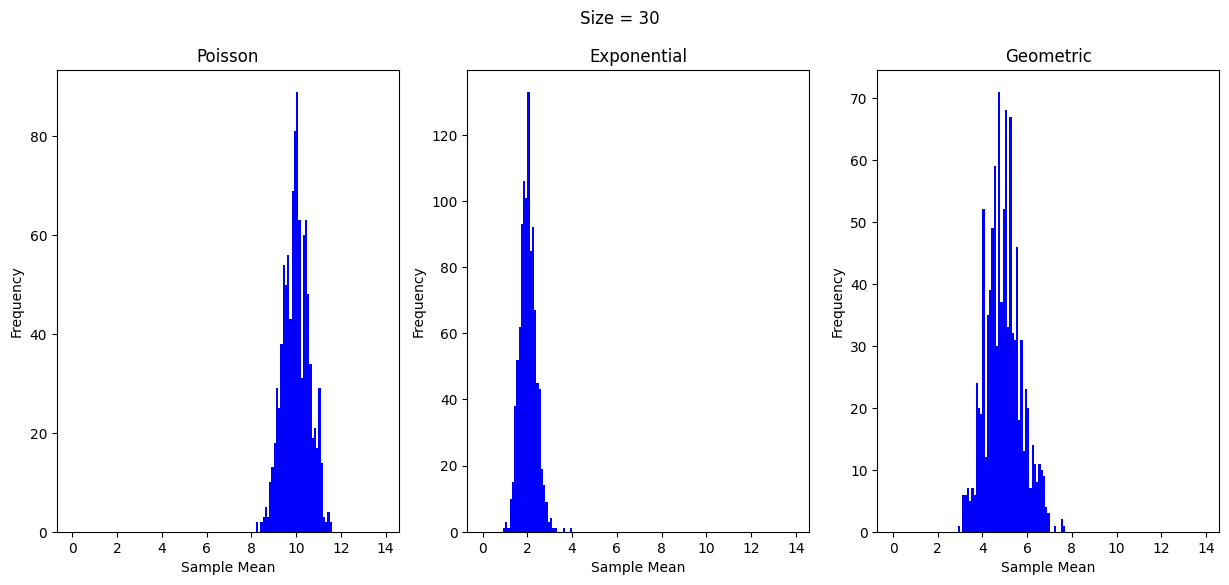

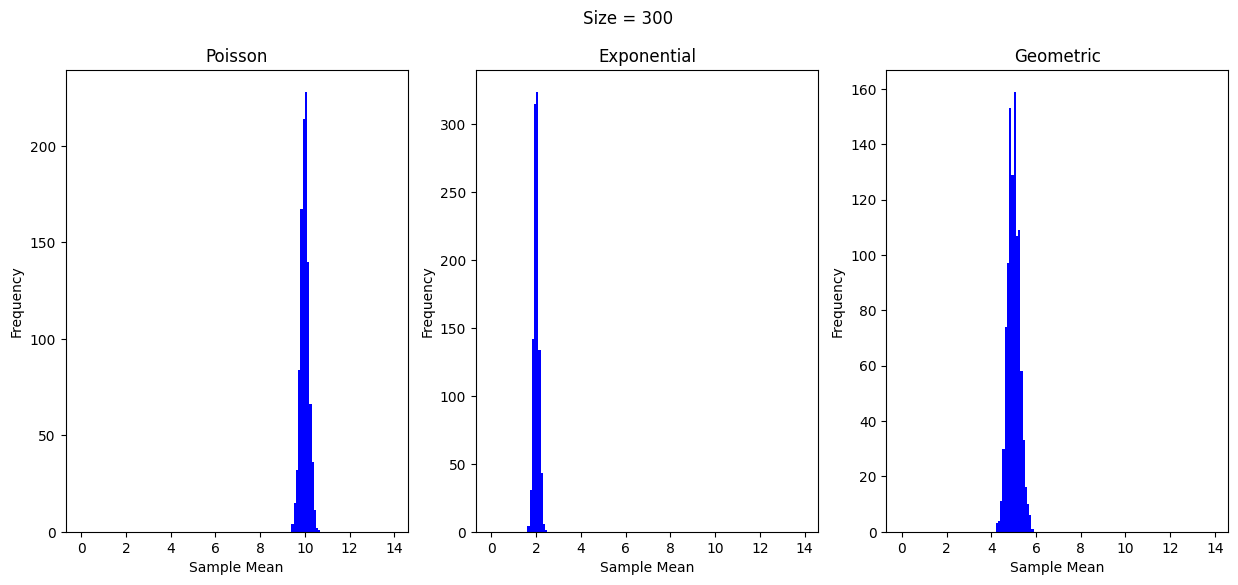

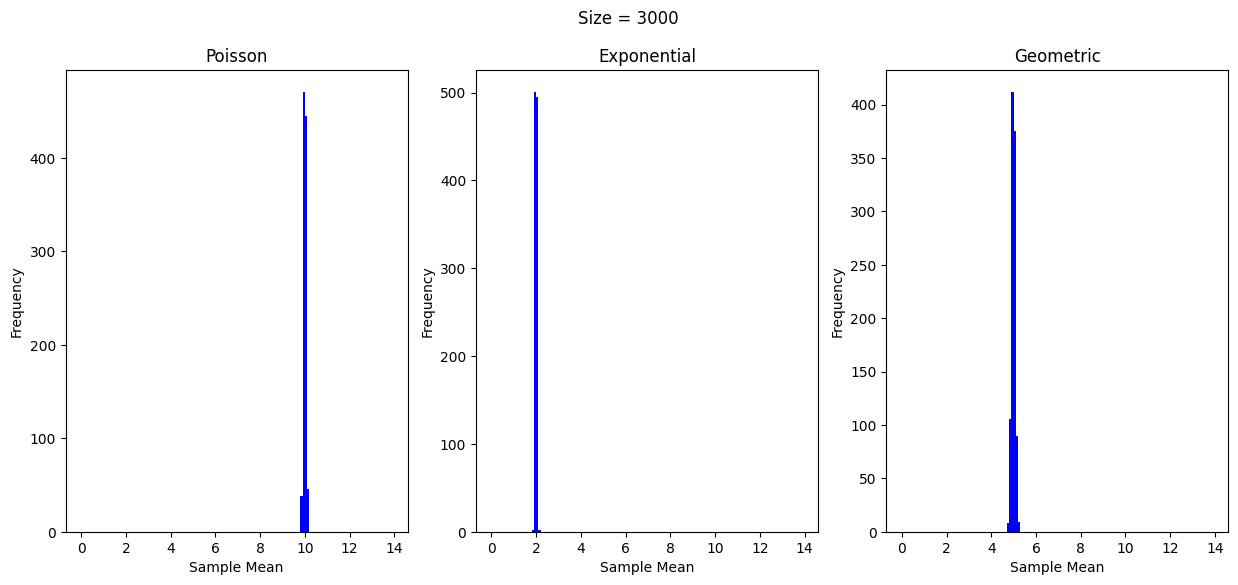

In [ ]:
np.random.seed(530)
sizes = [30,300,3000]
bins = np.arange(0,14,0.1)
for size in sizes:
    means = {"Poisson": [], "Exponential": [], "Geometric": []}
    for i in range(1000):
        samples= np.random.poisson(lambda_poisson,size)
        means["Poisson"].append(np.mean(samples))
        samples = np.random.exponential(1/lambda_exponential, size)
        means["Exponential"].append(np.mean(samples))
        samples = np.random.geometric(p_geometric, size)
        means["Geometric"].append(np.mean(samples))
    plt.figure(figsize=(15, 6))
    plt.suptitle("Size = %d" %size)
    plot_index = 1
    for distribution in means:
        plt.subplot(1,3,plot_index)
        plt.hist(means[distribution], bins=bins, color='blue')
        plt.title(distribution)
        plt.xlabel('Sample Mean')
        plt.ylabel('Frequency')
        plot_index += 1
    plt.show()



برای مقایسه بهتر نمودار های مربوط به هر کدام از 30،300 و 3000 برای توزیع ها کنار هم کشیده شده است

part3:

In [ ]:
np.random.seed(530)
for size in sizes:
    means = {"Poisson": [], "Exponential": [], "Geometric": []}
    for i in range(1000):
        samples= np.random.poisson(lambda_poisson,size)
        means["Poisson"].append(np.mean(samples))
        samples = np.random.exponential(1/lambda_exponential, size)
        means["Exponential"].append(np.mean(samples))
        samples = np.random.geometric(p_geometric, size)
        means["Geometric"].append(np.mean(samples))
    for distribution,mean in means.items():
        mean_of_means = np.mean(mean)
        std = np.std(mean)
        standard_error = std / np.sqrt(size)
        print("%s for sample size %d : \nmean = %.4f, \nSd = %.4f, \nstandard error = %.4f"
              % (distribution, size, mean_of_means, std, standard_error))
    print('----------------------------------------')

Poisson for sample size 30 : 
mean = 9.9968, 
Sd = 0.5741, 
standard error = 0.1048
Exponential for sample size 30 : 
mean = 2.0203, 
Sd = 0.3625, 
standard error = 0.0662
Geometric for sample size 30 : 
mean = 4.9504, 
Sd = 0.7850, 
standard error = 0.1433
----------------------------------------
Poisson for sample size 300 : 
mean = 9.9902, 
Sd = 0.1800, 
standard error = 0.0104
Exponential for sample size 300 : 
mean = 2.0025, 
Sd = 0.1141, 
standard error = 0.0066
Geometric for sample size 300 : 
mean = 5.0018, 
Sd = 0.2586, 
standard error = 0.0149
----------------------------------------
Poisson for sample size 3000 : 
mean = 10.0002, 
Sd = 0.0590, 
standard error = 0.0011
Exponential for sample size 3000 : 
mean = 2.0003, 
Sd = 0.0366, 
standard error = 0.0007
Geometric for sample size 3000 : 
mean = 4.9955, 
Sd = 0.0815, 
standard error = 0.0015
----------------------------------------


باتوجه به نتایج بالا برای هر توزیع در اندازه نمونه های متفاوت، میتوان گفت با افزایش تعداد به مقدار تئوری در محاسبه میانگین و واریانس نزدیک میشویم و خطا کمتر شده است

part4:

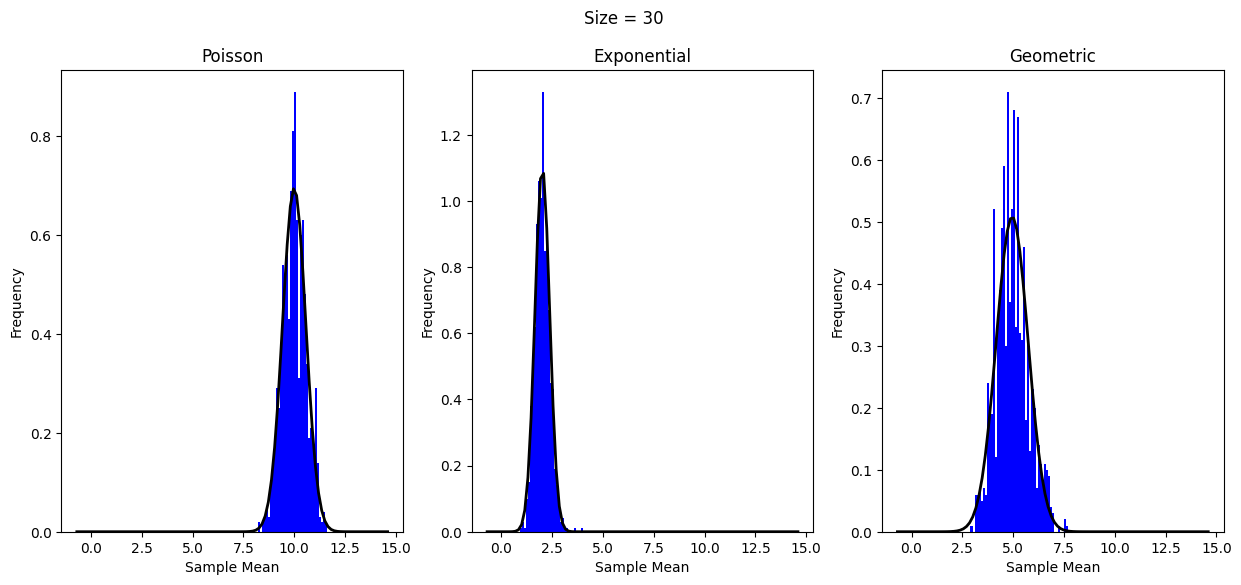

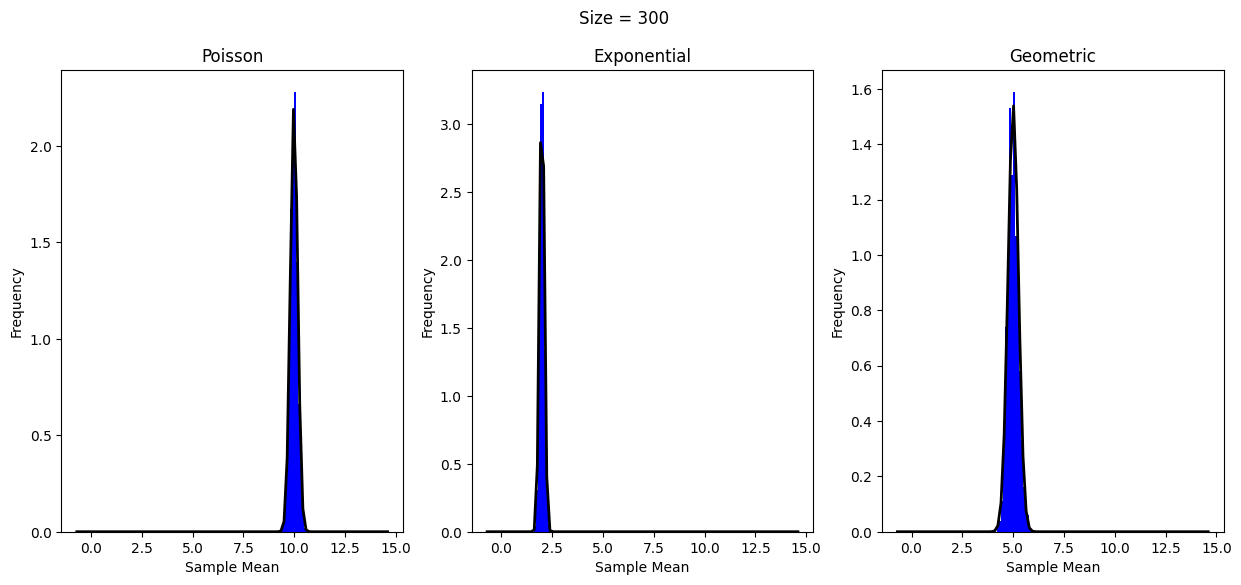

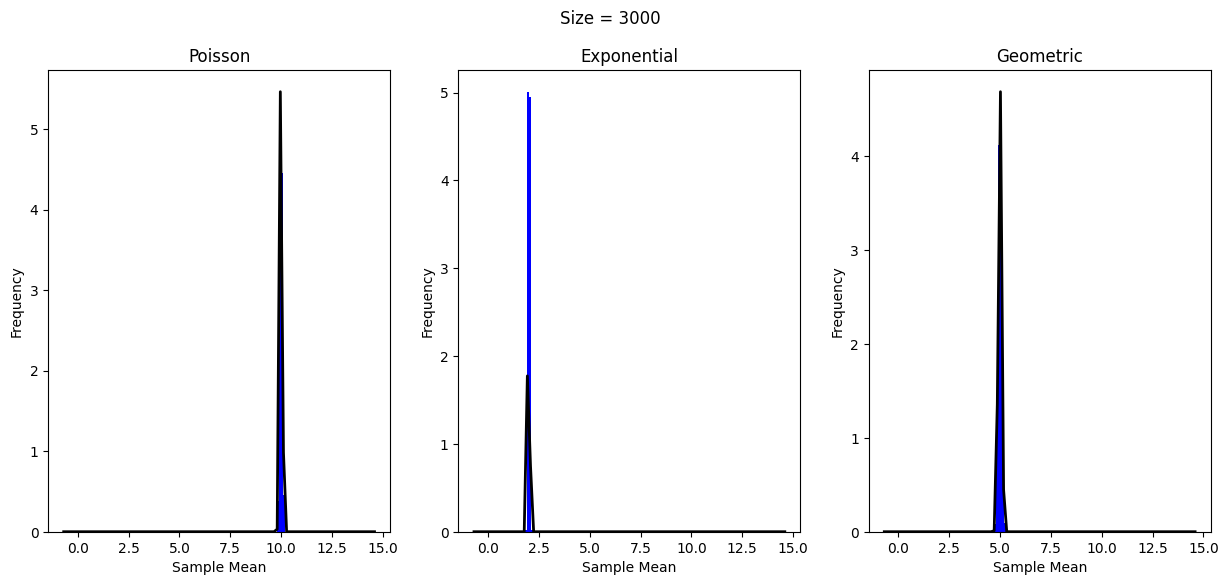

In [ ]:
np.random.seed(530)
sizes = [30,300,3000]
bins = np.arange(0,14,0.1)
for size in sizes:
    means = {"Poisson": [], "Exponential": [], "Geometric": []}
    for i in range(1000):
        samples= np.random.poisson(lambda_poisson,size)
        means["Poisson"].append(np.mean(samples))
        samples = np.random.exponential(1/lambda_exponential, size)
        means["Exponential"].append(np.mean(samples))
        samples = np.random.geometric(p_geometric, size)
        means["Geometric"].append(np.mean(samples))
    plt.figure(figsize=(15, 6))
    plt.suptitle("Size = %d" %size)
    plot_index = 1
    for distribution, mean in means.items():
        mean_of_means = np.mean(mean)
        std = np.std(mean)
        plt.subplot(1,3,plot_index)
        plt.hist(mean, bins=bins, color='blue', density= True)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_of_means, std)
        plt.plot(x, p, 'k', linewidth=2, label='Normal')
        plt.title(distribution)
        plt.xlabel('Sample Mean')
        plt.ylabel('Frequency')
        plot_index += 1
    plt.show()

Based on large number law:

با افزایش داده ها از 30 به 3000 در واثع تعداد فضای نمونه زیاد میشود و احتمال یا پارامتر ما در مقایسه با آن کوچک است باتوجه به مطالبی که گفته شده میدانیم در این وضعیت میتوان تقریب خوبی به نرمال زد (مشترکا نرمال)و در واقع با افزایش نمونه ها دو نمودار بیشتر روی هم منطبق شده اند و میتوان گفت به توزیع نرمال با پارامتر خودش نزدیک میشوند
به نوعی به دنبال نشان دادن توزیع عای مختلف با نرمال یا گوسی برای دیدن حد مرکزی بودیم که درست شد

Part 5


distribution for sample size 30 : 
mean = 5.5629, 
Sd = 3.2655, 
standard error = 0.5962


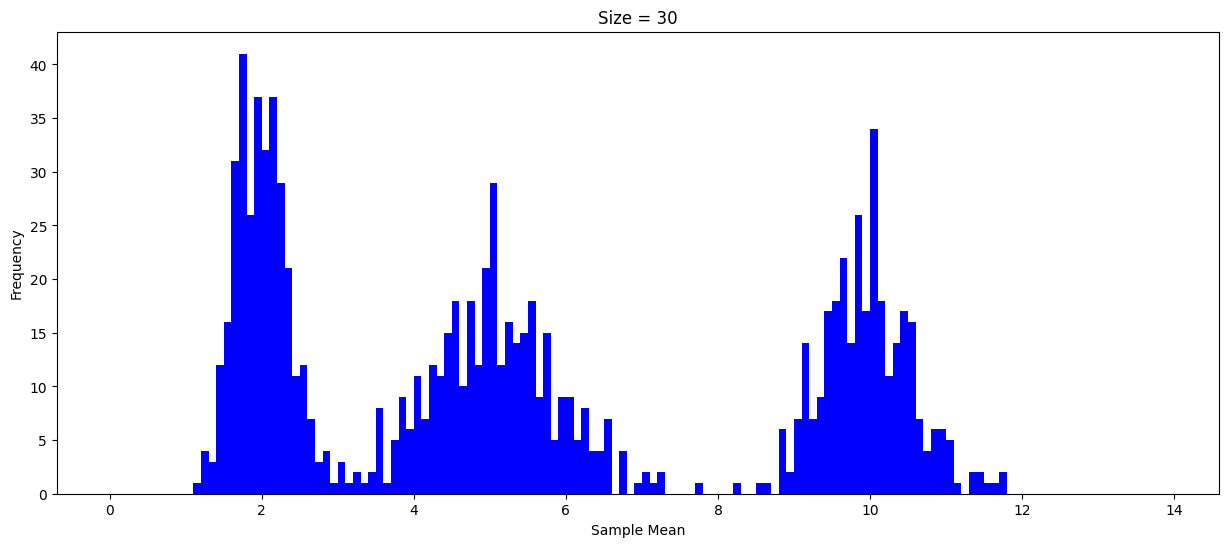

distribution for sample size 300 : 
mean = 5.5298, 
Sd = 3.3022, 
standard error = 0.1907


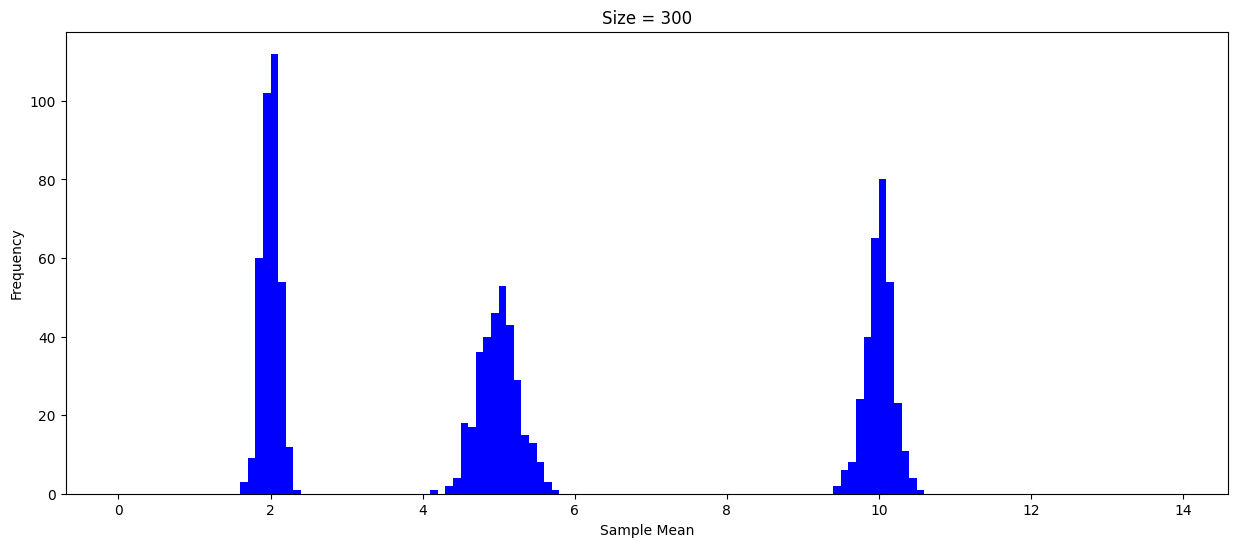

distribution for sample size 3000 : 
mean = 5.6991, 
Sd = 3.2722, 
standard error = 0.0597


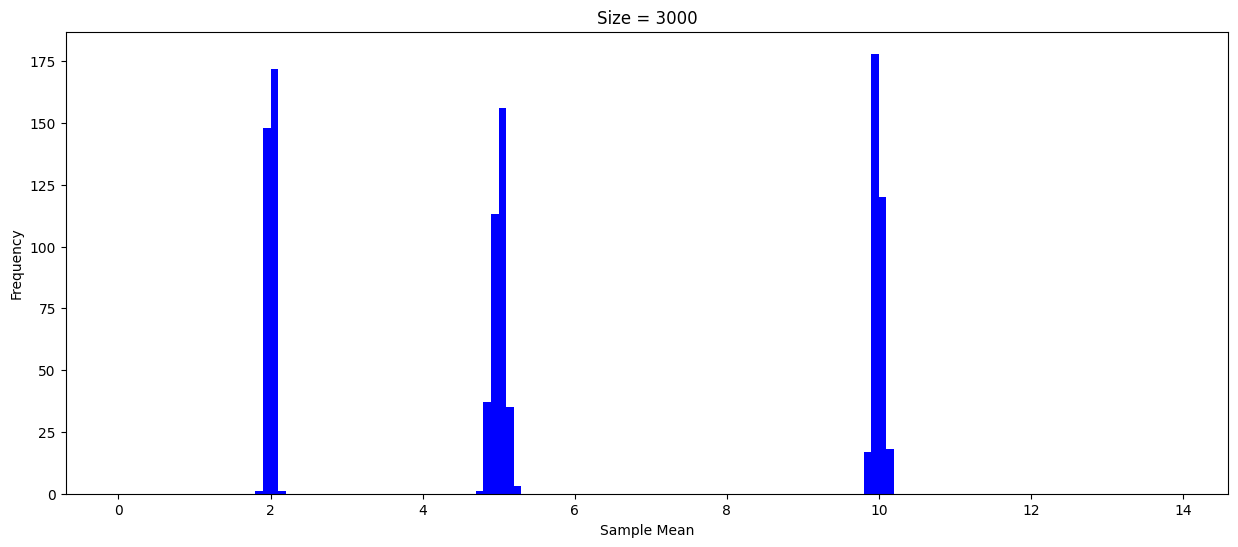

In [ ]:
np.random.seed(530)
sizes = [30,300,3000]
bins = np.arange(0,14,0.1)
for size in sizes:
    means = []
    for i in range(1000):
        rand = random.randint(1,3)
        if rand == 1:
            samples = np.random.poisson(lambda_poisson,size)
        elif rand == 2:
            samples = np.random.exponential(1/lambda_exponential, size)
        else:
            samples = np.random.geometric(p_geometric, size)
        means.append(np.mean(samples))
    plt.figure(figsize=(15, 6))
    mean_of_means = np.mean(means)
    std = np.std(means)
    standard_error = std / np.sqrt(size)
    print("distribution for sample size %d : \nmean = %.4f, \nSd = %.4f, \nstandard error = %.4f"
        % (size, mean_of_means, std, standard_error))
    plt.hist(means, bins=bins, color='blue')
    plt.title("Size = %d" %size)
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')
    plt.show()

part6:

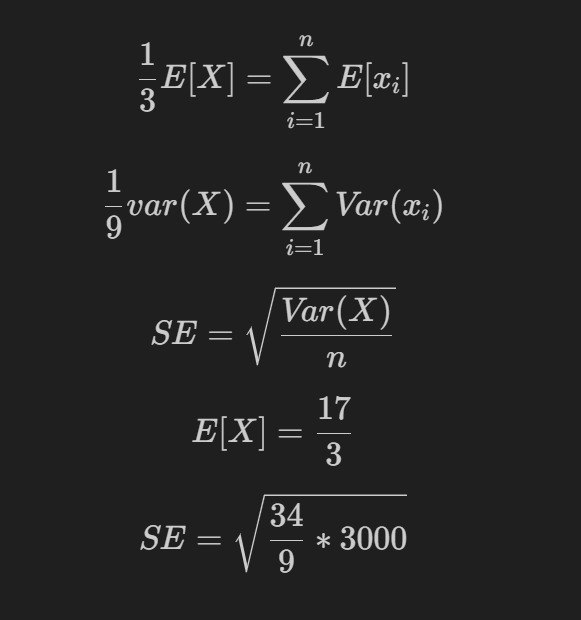

part7:


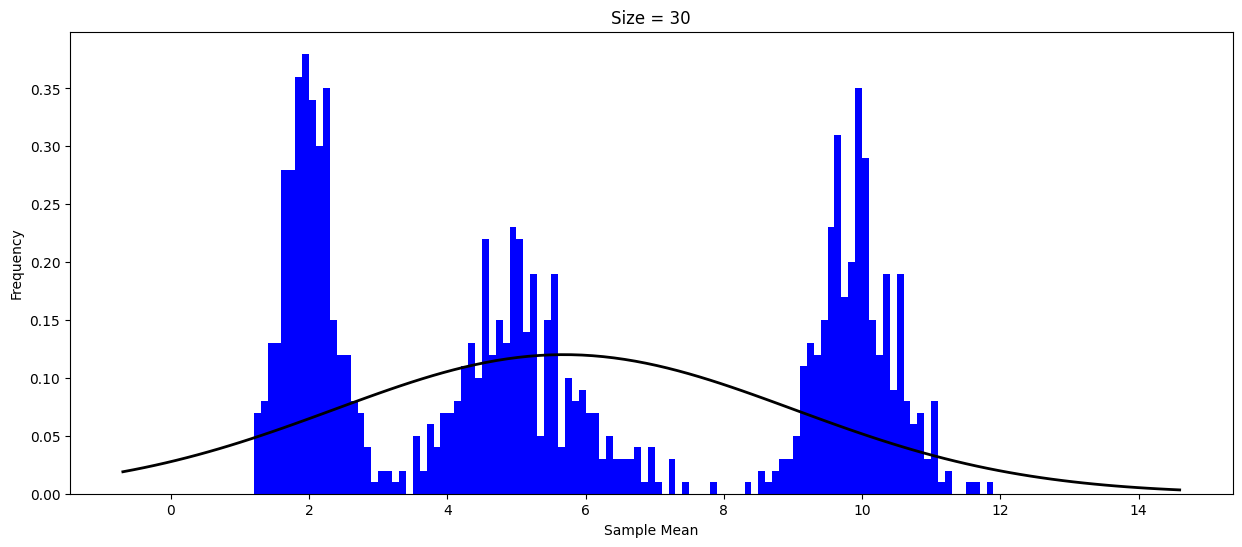

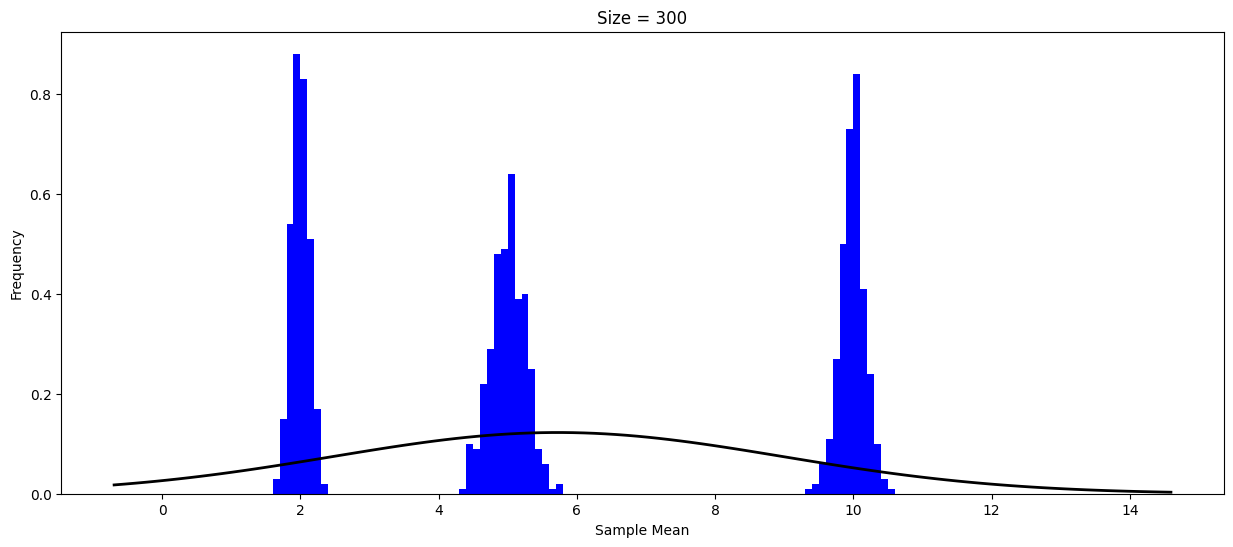

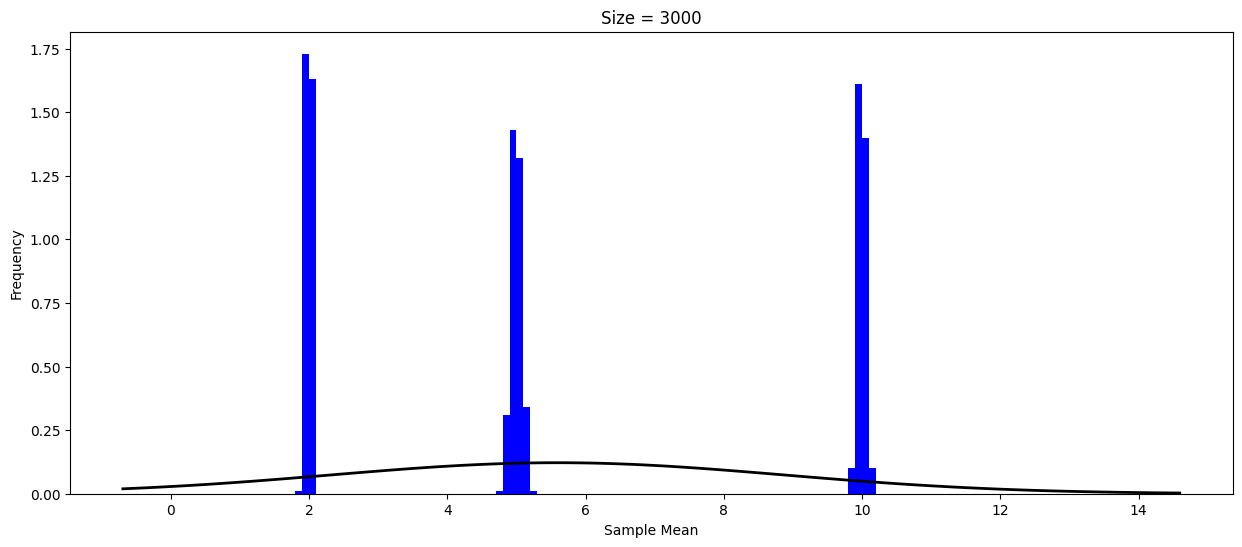

In [ ]:
np.random.seed(530)
sizes = [30,300,3000]
bins = np.arange(0,14,0.1)
for size in sizes:
    means = []
    for i in range(1000):
        rand = random.randint(1,3)
        if rand == 1:
            samples = np.random.poisson(lambda_poisson,size)
        elif rand == 2:
            samples = np.random.exponential(1/lambda_exponential, size)
        else:
            samples = np.random.geometric(p_geometric, size)
        means.append(np.mean(samples))
    plt.figure(figsize=(15, 6))
    mean_of_means = np.mean(means)
    std = np.std(means)
    plt.hist(means, bins=bins, color='blue', density= True)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean_of_means, std)
    plt.plot(x, p, 'k', linewidth=2, label='Normal')
    plt.title('Size = %d' %size)
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')
    plt.show()

اینجا آنچه در سوال 4 مشاهده شد را نمیتوان نتیجه گرفت و نمودار ها بر نرمالشان منطبق نیست پس مشترکا نرمال نمیباشد(توزیع ها متفاوت اند با ابنکه نمونه افزایش دارد)
اگر توزیع ها را متغیر در نظر بگیریم که از هم مستقل اند،با هم توزیع یکسانی ندارد که مجموع آن هارا نرمال بگیریم.
Based on iid on clt.